# Urban Sound Classification with Deep Learning

### Raw-waveform recurrence, log-Mel feature engineering, convolutional modeling, and SpecAugment

`Python` · `PyTorch` · `torchaudio` · `Audio Classification` · `Deep Learning` · `Signal Processing`

## Project overview

This project develops a complete environmental-audio classification workflow for the UrbanSound8K dataset. It begins with a recurrent baseline trained directly on raw waveforms, derives log-Mel spectrograms step by step, compares recurrent and convolutional architectures, and evaluates SpecAugment as a regularization strategy.

The experiments address three practical questions:

- How much does an audio-specific time–frequency representation improve over raw samples?
- Is a convolutional model better suited to spectrogram structure than a recurrent model?
- Can time and frequency masking improve generalization on a relatively small training set?

Saved validation results show a clear progression from **11.76%** accuracy for the raw-waveform baseline to **92.73%** for the augmented convolutional model.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torchaudio
from IPython import display
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset

%matplotlib inline

# GPU acceleration is used for model training.
device = "cuda:0"

## Dataset and classification task

The project uses [UrbanSound8K](https://urbansounddataset.weebly.com/urbansound8k.html), a benchmark collection of 8,732 labeled urban sound clips. The prepared split used here contains **4,500 training clips** and **935 validation clips**.

Each recording belongs to one of ten classes:

`air_conditioner`, `car_horn`, `children_playing`, `dog_bark`, `drilling`, `engine_idling`, `gun_shot`, `jackhammer`, `siren`, and `street_music`.

The task is a ten-class supervised classification problem evaluated with validation accuracy and normalized confusion matrices.

### Lazy-loading audio dataset

`AudioDataset` loads WAV files only when requested by the data loader, avoiding permanent storage of the full audio collection in memory. Each sample is resampled to 44.1 kHz when necessary, padded to a common length of 384,000 samples, and returned with its original length and encoded class label.

The following cells download the prepared data, validate dataset dimensions, visualize a waveform, play an example clip, and construct mini-batch loaders.

In [6]:
link = 'https://disk.yandex.ru/d/LXmjlqdXsgseoQ' # The link to the dataset

import requests
url = f"https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key={link}"
response = requests.get(url)
download_url = response.json()["href"]

with open("data.zip", "wb") as file:
    download_response = requests.get(download_url, stream=True)
    for chunk in download_response.iter_content(chunk_size=1024):
        if chunk:
            file.write(chunk)
            file.flush()

! unzip data.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/data/1677.wav      
  inflating: data/data/1678.wav      
  inflating: data/data/1679.wav      
  inflating: data/data/168.wav       
  inflating: data/data/1680.wav      
  inflating: data/data/1681.wav      
  inflating: data/data/1686.wav      
  inflating: data/data/1687.wav      
  inflating: data/data/1688.wav      
  inflating: data/data/1689.wav      
  inflating: data/data/1690.wav      
  inflating: data/data/1695.wav      
  inflating: data/data/1697.wav      
  inflating: data/data/1699.wav      
  inflating: data/data/17.wav        
  inflating: data/data/170.wav       
  inflating: data/data/1701.wav      
  inflating: data/data/1702.wav      
  inflating: data/data/1703.wav      
  inflating: data/data/1704.wav      
  inflating: data/data/1705.wav      
  inflating: data/data/1706.wav      
  inflating: data/data/1708.wav      
  inflating: data/data/1709.wav      
  inflating: data/data/171.wav       

In [7]:
# UrbanSound8K class labels
classes = [
    "air_conditioner",
    "car_horn",
    "children_playing",
    "dog_bark",
    "drilling",
    "engine_idling",
    "gun_shot",
    "jackhammer",
    "siren",
    "street_music",
]

In [8]:
class AudioDataset(Dataset):
    def __init__(
        self,
        path_to_csv: str,
        path_to_folder: str,
        pad_size: int = 384000,
        sr: int = 44100,
    ):
        self.csv: pd.DataFrame = pd.read_csv(path_to_csv)[["ID", "Class"]]
        self.path_to_folder = path_to_folder
        self.pad_size = pad_size

        self.sr = sr

        self.class_to_idx = {classes[i]: i for i in range(10)}

    def __getitem__(self, index: int):
        # Load and preprocess one audio clip on demand

        id, cl = self.csv.iloc[index]

        audio_path = self.path_to_folder + '/' + str(self.csv.iloc[index]["ID"])+'.wav'
        wav, s_rate = torchaudio.load(audio_path)
        wav = wav.squeeze()
        wav_size = len(wav)

        if s_rate != self.sr:
            resampler = torchaudio.transforms.Resampler(s_rate, self.sr)
            wav = resampler(wav)

        if len(wav) < self.pad_size:
            pad = (0, self.pad_size - len(wav))
            padding = nn.ConstantPad1d(pad, 0.0)
            wav = padding(wav)

        return {"len": wav_size, "x": wav, "y": self.class_to_idx[cl]}


    def __len__(self):
        return self.csv.shape[0]

In [10]:
# Creating datasets
train_dataset = AudioDataset("./data/train_part.csv", "./data/data")
val_dataset = AudioDataset("./data/val_part.csv", "./data/data")

In [11]:
# Validate split sizes
assert len(train_dataset) == 4500
assert len(val_dataset) == 935

In [ ]:
# Validate the dataset output contract
item = train_dataset.__getitem__(0)

assert item["x"].shape == (384000,)
assert item["y"] == 0
assert item["len"] == 176400

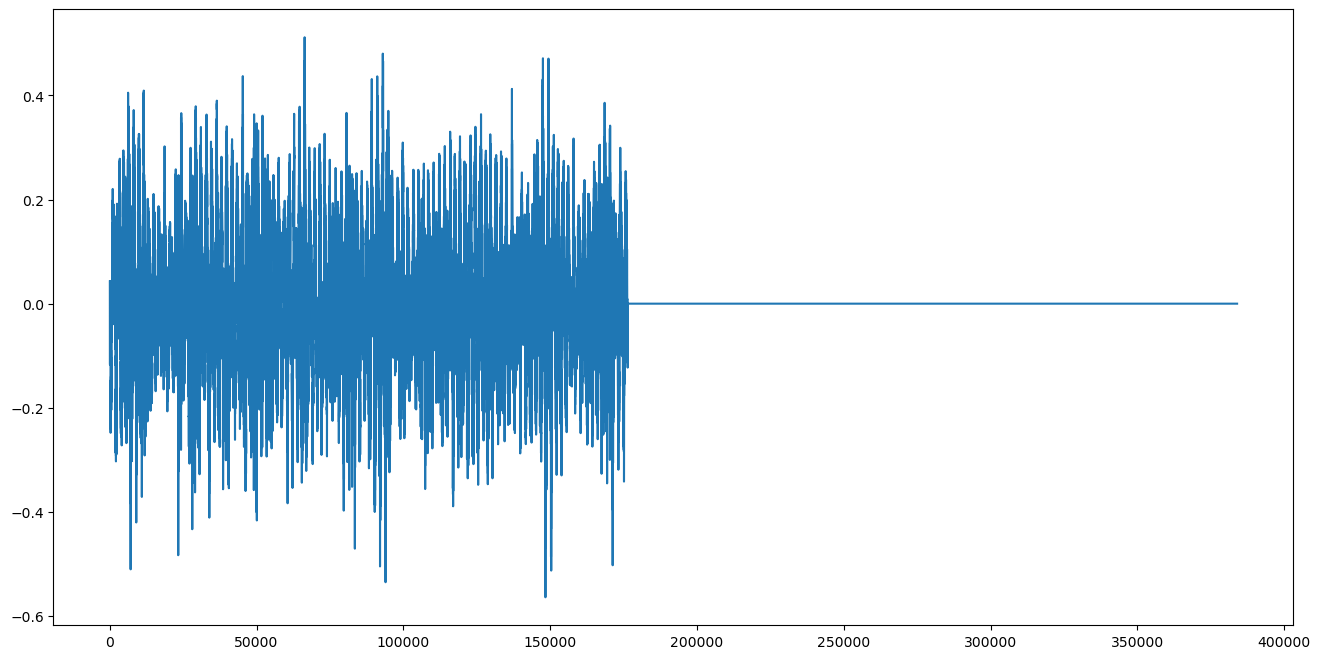

In [ ]:
# Visualize and play an example waveform
item = train_dataset.__getitem__(0)
plt.figure(figsize=(16, 8))
plt.plot(item["x"])

display.Audio(item["x"], rate=train_dataset.sr)

In [ ]:
# Create mini-batch data loaders
train_dataloader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, pin_memory=True, drop_last=True
)
val_dataloader = DataLoader(val_dataset, batch_size=32, pin_memory=True)

## Baseline model: bidirectional LSTM on raw waveforms

Audio can be treated as a long time series, but processing every sample recurrently would be prohibitively expensive. The baseline therefore:

1. divides each waveform into overlapping 1,024-sample windows with a 256-sample hop;
2. compresses each window through an MLP with dimensions `1024 → 256 → 64 → 16`;
3. processes the window sequence with a two-layer bidirectional LSTM;
4. concatenates the final hidden states and maps them through `1024 → 256 → 10` to class logits.

Batch normalization is included in the dense blocks to stabilize optimization.

In [ ]:
class RecurrentRawAudioClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        window_length=1024,
        hop_length=256,
        hidden=256,
        num_layers=2,
    ) -> None:
        super().__init__()

        self.window_length = window_length
        self.hop_length = hop_length

        # Window encoder, recurrent backbone, and classification head
        self.first_mlp = nn.Sequential(
            nn.Linear(window_length, hop_length),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 16),
            nn.ReLU()
        )

        self.rnn = nn.LSTM(16, hidden_size=hidden, bidirectional=True, num_layers=num_layers)

        self.final_mlp =  nn.Sequential(
            nn.Linear(2 * hidden * num_layers, 256),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x, lens) -> torch.Tensor:
        # Split each waveform into overlapping frames
        # batch_windows.shape == (B, NUM WINDOWS, 1024)
        batch_windows = x.unfold(1, 1024, 256)

        # Encode every frame with the shared MLP
        # batch_windows_feautures.shape == (B, NUM WINDOWS, 16)
        batch_windows_feautures = torch.stack(list(map(self.first_mlp, batch_windows)))
        batch_windows_feautures = batch_windows_feautures.permute(1,0,2)

        # Process the frame sequence and retain the final hidden states
        output, (hidden_state, cl) = self.rnn(batch_windows_feautures)

        # Concatenate directions and recurrent layers
        # hidden_flattened.shape = (B, 2 * hidden_size * num_layers)
        hidden_state = hidden_state.permute(1, 0, 2)
        hidden_flattened =  torch.stack(list(map(torch.flatten, hidden_state)))

        # Convert the sequence representation into class logits
        return self.final_mlp(hidden_flattened)

### Training loop

The shared training function supports optional feature extraction and augmentation. It tracks cross-entropy loss and mini-batch accuracy, periodically visualizes optimization progress, and switches the trained model to evaluation mode.

In [ ]:
def train_audio_clfr(
    model,
    optimizer,
    train_dataloader,
    sr,
    criterion=torch.nn.CrossEntropyLoss(),
    data_transform=None,
    augmentation=None,
    num_epochs=10,
    device="cuda:0",
    verbose_num_iters=10,
):
    model.train()
    iter_i = 0

    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        for batch in train_dataloader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            lens = batch["len"].to(device)

            # Apply optional feature extraction
            if data_transform:
                x, lens = data_transform(x, lens, device=device, sr=sr)

            # Apply optional spectrogram augmentation
            if augmentation:
                x, lens = augmentation(x, lens)

            probs = model(x, lens)
            optimizer.zero_grad()
            loss = criterion(probs, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            # Track mini-batch accuracy
            pred_cls = probs.argmax(dim=-1)
            train_accuracies.append((pred_cls == y).float().mean().item())

            iter_i += 1

            # Periodically visualize optimization progress
            if iter_i % verbose_num_iters == 0:
                clear_output(wait=True)

                print(f"Epoch {epoch}")

                plt.figure(figsize=(10, 5))

                plt.subplot(1, 2, 1)
                plt.xlabel("Iteration")
                plt.ylabel("Train loss")
                plt.plot(np.arange(iter_i), train_losses)

                plt.subplot(1, 2, 2)
                plt.xlabel("Iteration")
                plt.ylabel("Train acc")
                plt.plot(np.arange(iter_i), train_accuracies)

                plt.show()

    model.eval()

In [ ]:
# Initialize the raw-waveform model and optimizer
rnn_raw = RecurrentRawAudioClassifier()
rnn_raw.to(device)
optim = torch.optim.Adam(rnn_raw.parameters(), lr=3e-4)

Epoch 9


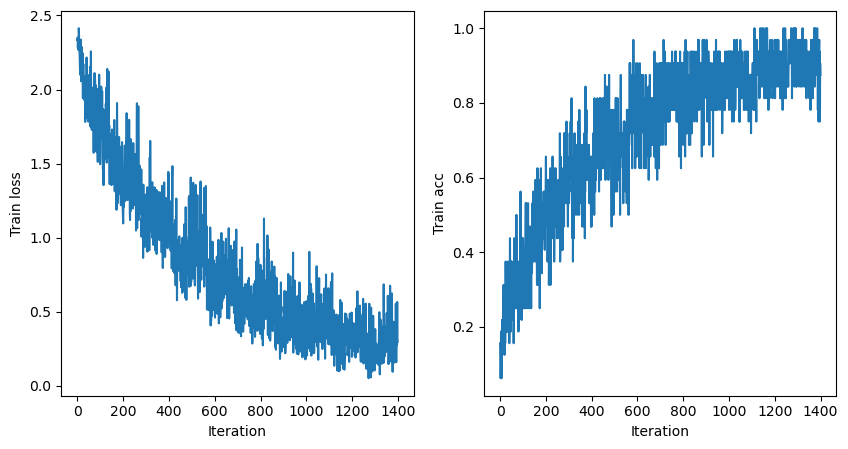

In [ ]:
# Train the raw-waveform baseline
train_audio_clfr(rnn_raw, optim, train_dataloader, train_dataset.sr)

### Baseline validation

Validation performance is measured with overall accuracy and a row-normalized confusion matrix, allowing both aggregate and class-specific behavior to be inspected.

In [ ]:
def plot_confusion_matrix(model, val_dataloader, sr, device, data_transform=None):
    pred_true_pairs = []
    for batch in val_dataloader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        lens = batch["len"].to(device)

        with torch.no_grad():
            if data_transform:
                x, lens = data_transform(x, lens, sr=sr, device=device)

            probs = model(x, lens)

            pred_cls = probs.argmax(dim=-1)

        for pred, true in zip(pred_cls.cpu().detach().numpy(), y.cpu().numpy()):
            pred_true_pairs.append((pred, true))

    print(f"Val accuracy: {np.mean([p[0] == p[1] for p in pred_true_pairs])}")

    cm_df = pd.DataFrame(
        confusion_matrix(
            [p[1] for p in pred_true_pairs],
            [p[0] for p in pred_true_pairs],
            normalize="true",
        ),
        columns=classes,
        index=classes,
    )
    sn.heatmap(cm_df, annot=True)

Val accuracy: 0.11764705882352941


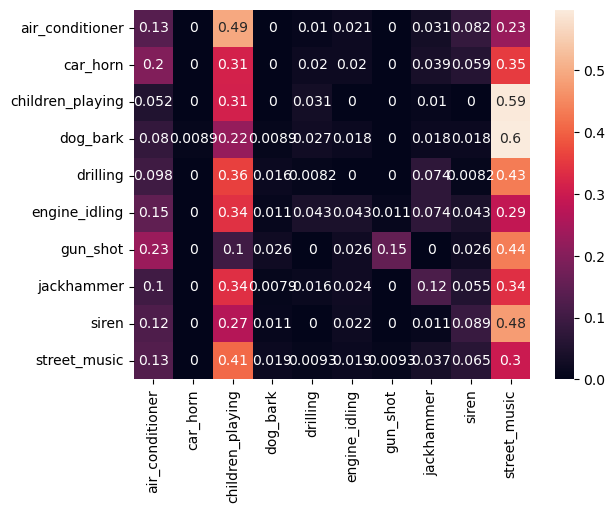

In [ ]:
plot_confusion_matrix(rnn_raw, val_dataloader, train_dataset.sr, device)

### Raw-waveform result

The raw-waveform recurrent baseline reaches only **11.76% validation accuracy**, despite training accuracy approaching 90%. Its confusion matrix shows predictions collapsing primarily into `children_playing` and `street_music`, with several classes receiving almost no correct predictions.

This large generalization gap indicates severe overfitting and confirms that raw samples are an inefficient representation for this dataset. A more stable time–frequency representation is needed.

## Log-Mel spectrogram feature engineering

Raw audio is highly sensitive to phase, amplitude, background noise, and small temporal shifts. Log-Mel spectrograms provide a more compact and perceptually meaningful representation by describing how frequency energy evolves through time.

The notebook constructs this representation manually:

1. split each waveform into overlapping frames;
2. apply a Hann window to reduce spectral leakage;
3. calculate the discrete Fourier transform and power spectrum;
4. project frequencies through a Mel filter bank;
5. clamp small values and apply logarithmic compression.

The manual result is compared with `torchaudio.transforms.MelSpectrogram` and verified numerically.

In [ ]:
from torchaudio.transforms import MelSpectrogram


# Torchaudio reference implementation
def compute_log_melspectrogram_reference(wav_batch, lens, sr, device="cpu"):
    featurizer = MelSpectrogram(
        sample_rate=sr,
        n_fft=1024,
        win_length=1024,
        hop_length=256,
        n_mels=64,
        center=False,
    ).to(device)

    return torch.log(featurizer(wav_batch).clamp(1e-5)), lens // 256

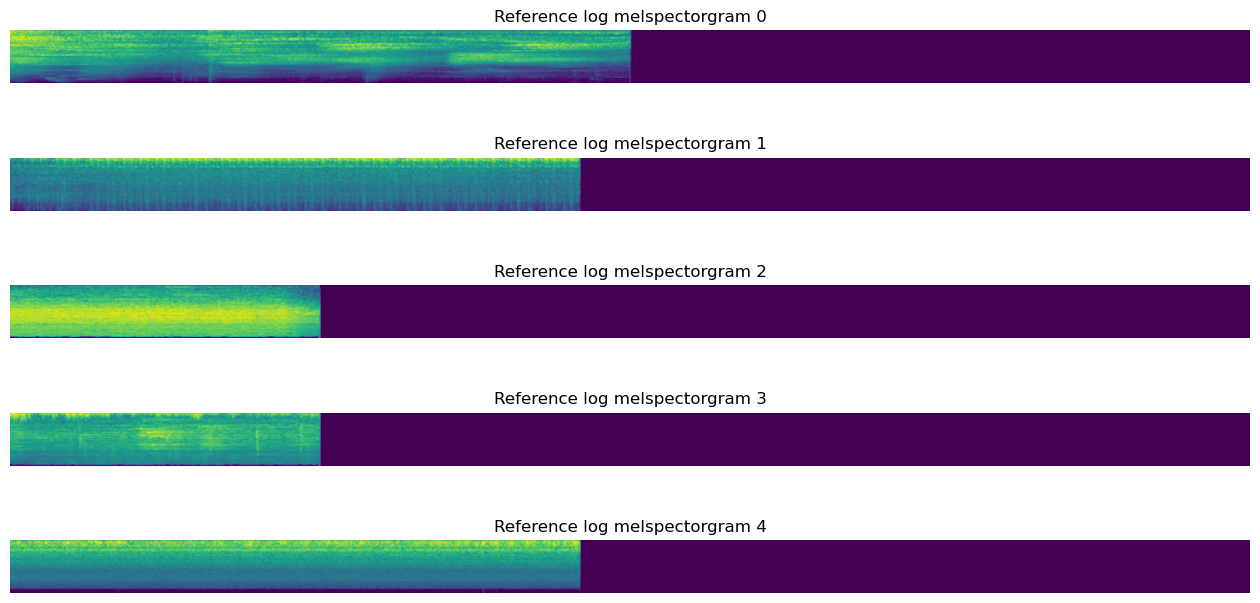

In [ ]:
# Select one training batch
for batch in train_dataloader:
    break

wav_batch = batch["x"]
lens = batch["len"]

# Compute reference log-Mel spectrograms
log_melspect, lens = compute_log_melspectrogram_reference(
    wav_batch, lens, train_dataset.sr
)

# Visualize reference features
fig, axes = plt.subplots(5, figsize=(16, 8))

for i in range(5):
    axes[i].axis("off")
    axes[i].set_title(f"Reference log melspectorgram {i}")
    axes[i].imshow(log_melspect[i].numpy())

### Manual implementation

The following steps reproduce the reference transformation from lower-level tensor operations.

In [ ]:
sr = train_dataset.sr
n_fft = 1024
win_length = 1024
hop_length = 256
n_mels = 64

The waveform batch is first divided into 1,024-sample frames with a 256-sample hop using `Tensor.unfold`.

In [ ]:
windows = wav_batch.unfold(1, win_length, hop_length)
assert windows.shape == (32, 1497, 1024)

A single frame is visualized and played to connect the windowed tensor representation with the underlying sound.

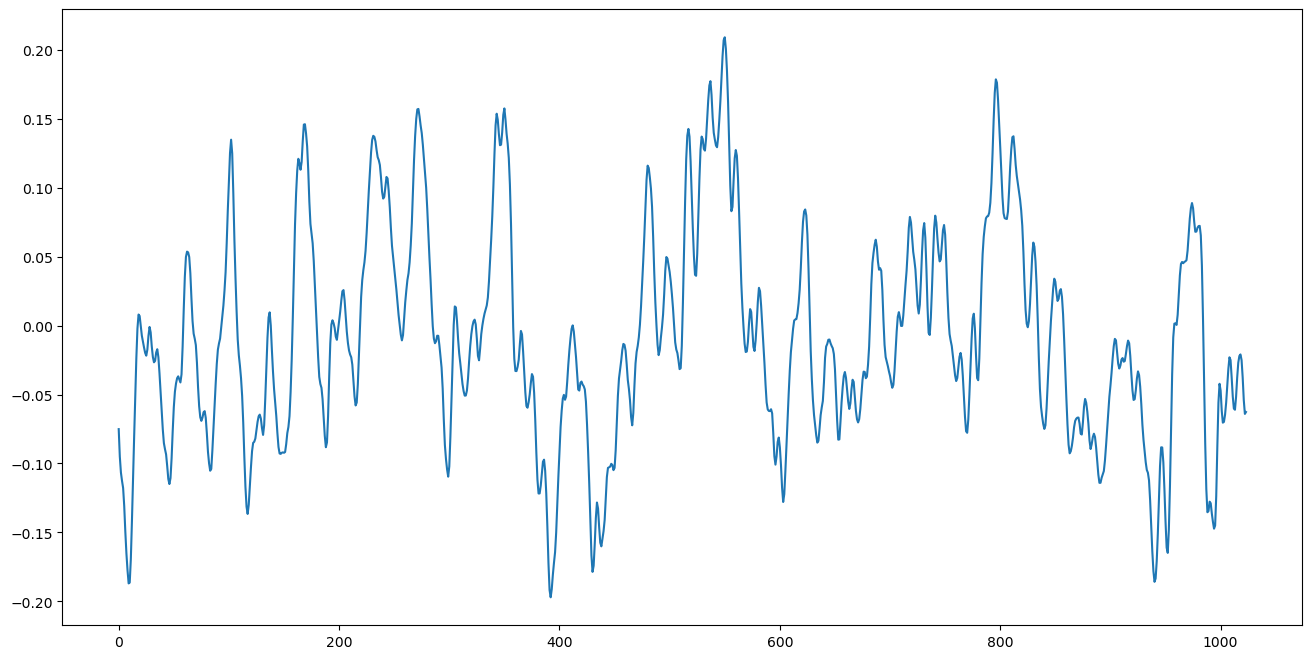

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(windows[0, 0])

display.Audio(windows[0, 0], rate=train_dataset.sr)

A Hann window is applied elementwise to every frame to reduce discontinuities at frame boundaries and limit spectral leakage.

In [ ]:
filter = torch.hann_window(win_length, periodic=True)  # Hann window
windows_with_applied_filter = windows * filter[None, None, :]

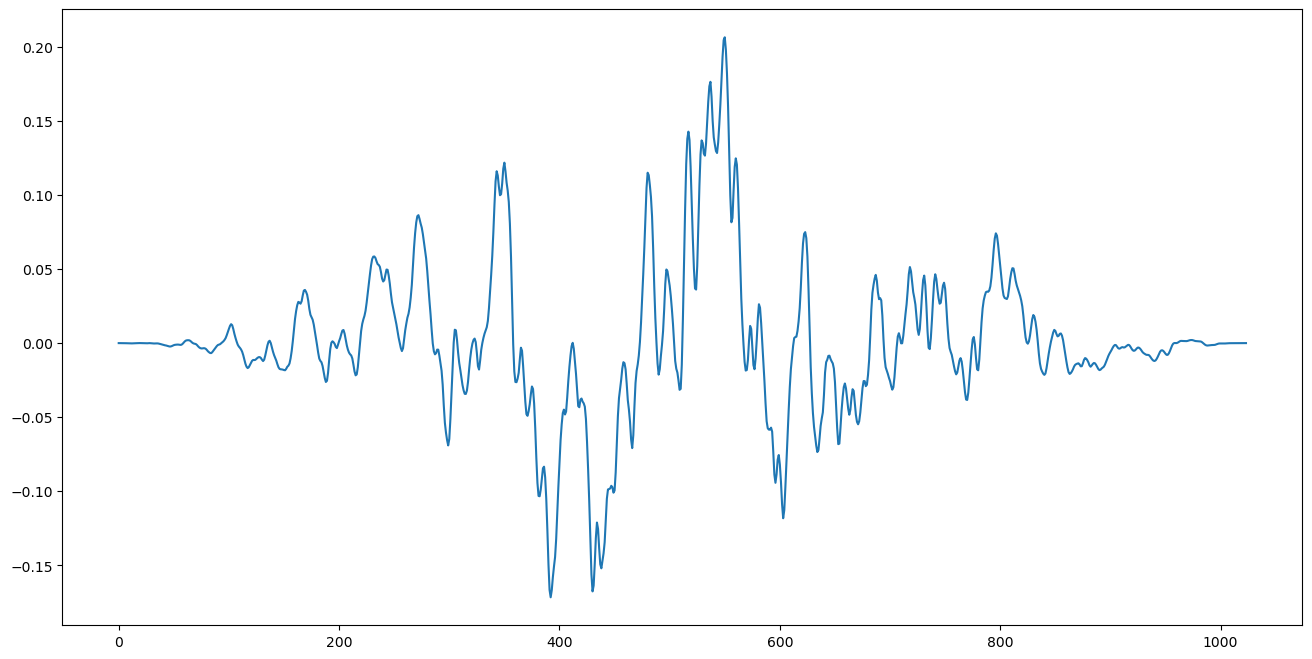

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(windows_with_applied_filter[0, 0])

display.Audio(windows_with_applied_filter[0, 0], rate=train_dataset.sr)

The discrete Fourier transform is calculated for every frame. Only the nonredundant positive-frequency components are retained, and their squared magnitudes form the power spectrum.

In [ ]:
fft_features = torch.fft.fft(windows_with_applied_filter)[:, :, :n_fft//2 + 1]  # Positive-frequency spectrum
fft_magnitudes = torch.abs(fft_features**2)
assert fft_magnitudes.shape == (32, 1497, 513)

A 64-band Mel filter bank converts the linear-frequency power spectrum into a perceptually motivated frequency scale.

In [ ]:
melscale = torchaudio.transforms.MelScale(n_mels = n_mels, sample_rate = sr, n_stft = n_fft // 2 + 1)  # Mel filter bank

The filter-bank visualization shows the overlapping triangular filters used to aggregate nearby Fourier frequencies into Mel bands.

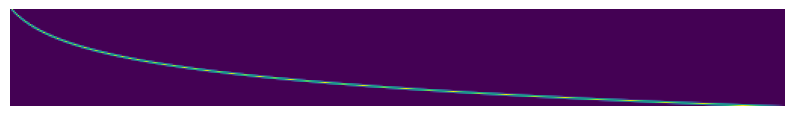

In [ ]:
plt.figure(figsize=(10, 5))
plt.axis("off")
plt.imshow(melscale.fb.numpy().transpose())

The Mel filter bank is applied to each frame-level power spectrum, producing a tensor with 64 frequency bands over time.

In [ ]:
mel_spectrogram = melscale(fft_magnitudes.transpose(2, 1))  # Project onto the Mel scale
assert mel_spectrogram.shape == (32, 64, 1497)

Values are clamped at $10^{-5}$ before logarithmic compression to avoid numerical instability from taking the logarithm of zero.

In [ ]:
logmel_spectrogram =  torch.log(mel_spectrogram.clamp_(1e-5))  # Log compression
assert logmel_spectrogram.shape == (32, 64, 1497)

The manually generated log-Mel spectrograms visually match the reference features.

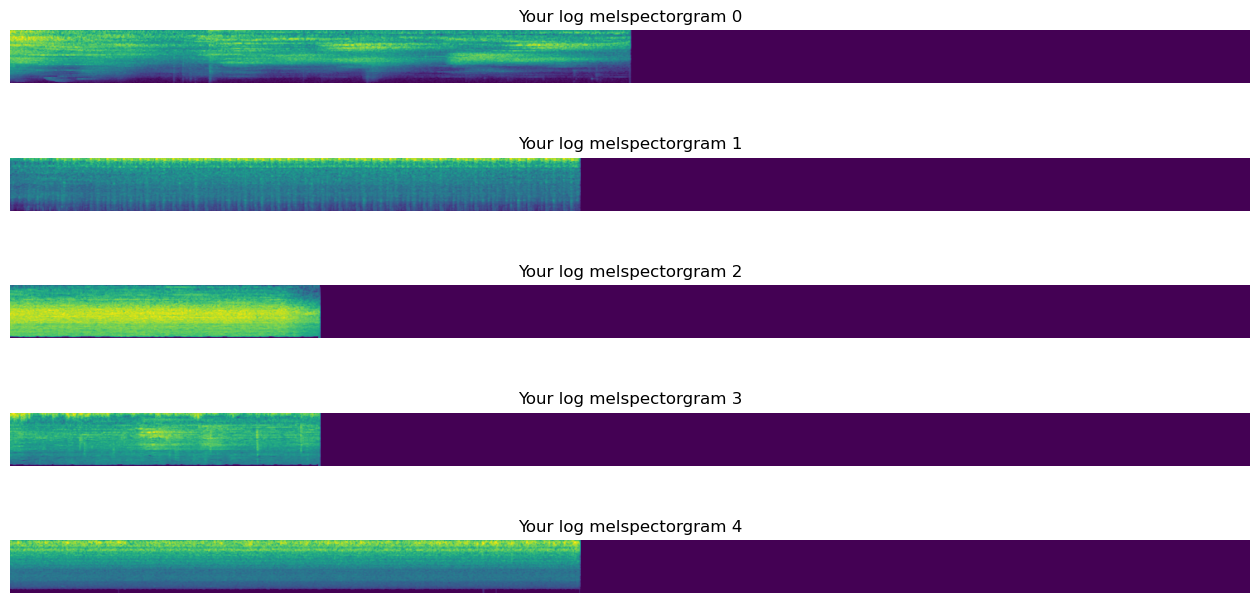

In [ ]:
# Visualize the manual implementation
fig, axes = plt.subplots(5, figsize=(16, 8))

for i in range(5):
    axes[i].axis("off")
    axes[i].set_title(f"Your log melspectorgram {i}")
    axes[i].imshow(logmel_spectrogram[i].numpy())

The complete transformation is packaged as a reusable batch function for model training and validation.

In [ ]:
# Reusable manual log-Mel implementation
def compute_log_melspectrogram(wav_batch, lens, sr, device="cpu"):
    # Frame, window, transform, project, and compress
    wav_batch = wav_batch.cpu()
    windows = wav_batch.unfold(1, win_length, hop_length)

    filter = torch.hann_window(win_length)
    windows_with_applied_filter = windows * filter[None, None, :]

    fft_features = torch.fft.fft(windows_with_applied_filter)[:, :, :n_fft // 2 + 1]
    fft_magnitudes = torch.abs(fft_features ** 2)

    melscale = torchaudio.transforms.MelScale(n_mels=n_mels, sample_rate=sr, n_stft=n_fft // 2 + 1)
    mel_spectrogram = melscale(fft_magnitudes.transpose(1, 2))

    logmel_spectrogram = torch.log(mel_spectrogram.clamp_(1e-5))
    return logmel_spectrogram.to(device), lens // 256

A numerical check confirms that the manual implementation matches the torchaudio reference within an absolute tolerance of $10^{-5}$.

In [ ]:
assert torch.allclose(
    compute_log_melspectrogram_reference(wav_batch, lens, train_dataset.sr)[0],
    compute_log_melspectrogram(wav_batch, lens, train_dataset.sr)[0],
    atol=1e-5,
)

## Bidirectional LSTM on log-Mel spectrograms

The recurrent architecture is adapted to consume 64-dimensional Mel frames directly. A two-layer bidirectional LSTM summarizes the temporal sequence, and the concatenated hidden states feed a dense ten-class classifier.

In [ ]:
class RecurrentMelSpectClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        window_length=1024,
        hop_length=256,
        hidden=256,
        num_layers=2,
    ) -> None:
        super().__init__()

        self.window_length = window_length
        self.hop_length = hop_length

        # Bidirectional recurrent encoder and classification head
        self.rnn =  nn.LSTM(input_size = 64, bidirectional=True, num_layers=num_layers, hidden_size=hidden)

        self.final_mlp = nn.Sequential(
        nn.Linear(2 * hop_length * num_layers, hidden),
        nn.ReLU(),
        nn.BatchNorm1d(hidden),
        nn.Linear(hidden, num_classes),
        nn.ReLU()
        )

    def forward(self, x, lens):
        # Bidirectional recurrent encoder and classification head
        batch_windows_features = x.permute(2, 0, 1)

        output, (hidden_state, cl) = self.rnn(batch_windows_features)

        hidden_flattened = torch.stack(list(map(torch.flatten, hidden_state.permute(1, 0, 2))))

        return self.final_mlp(hidden_flattened)

In [ ]:
rnn_mel = RecurrentMelSpectClassifier()
rnn_mel.to(device)

optim = torch.optim.Adam(rnn_mel.parameters(), lr=2e-4)

Epoch 9


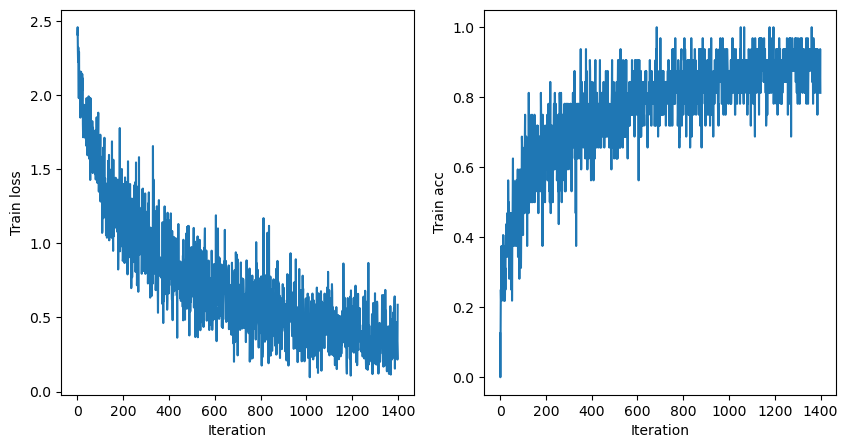

In [ ]:
train_audio_clfr(
    rnn_mel,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
)

### Log-Mel LSTM validation

The log-Mel recurrent model reaches **82.67% validation accuracy**, an improvement of more than 70 percentage points over the raw-waveform baseline. The strongest class recalls are observed for `engine_idling` (0.97), `jackhammer` (0.94), and `gun_shot` (0.92), while `street_music` remains the most difficult class at 0.55 recall.

Val accuracy: 0.8267379679144385


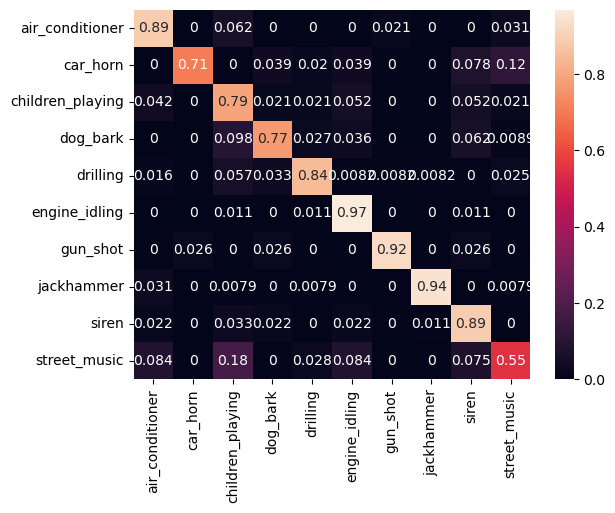

In [ ]:
plot_confusion_matrix(
    rnn_mel,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

## Convolutional classification of log-Mel spectrograms

Log-Mel spectrograms contain local time–frequency patterns that can be treated similarly to image textures. The convolutional model uses four feature stages:

- two 3×3 convolutions with 16 channels, followed by 2×2 max pooling;
- two 3×3 convolutions with 32 channels, followed by 2×2 max pooling;
- two 3×3 convolutions with 64 channels, followed by 2×2 max pooling;
- 128-channel convolutional layers, global max pooling, and a two-layer classifier.

Batch normalization and ReLU activations are used throughout. The design is inspired by convolutional audio architectures such as [PANNs](https://arxiv.org/abs/1912.10211).

In [ ]:
class CNN10(nn.Module):
    def __init__(self, num_classes=10, hidden=16):
        super().__init__()

        # Convolutional feature extractor and classification head
        self.cnn_backbone = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3), nn.BatchNorm2d(16), nn.ReLU(),
        nn.Conv2d(16, 16, kernel_size=3),nn.BatchNorm2d(16), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(16, 32, kernel_size=3), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3), nn.BatchNorm2d(32), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(32, 64, kernel_size=3), nn.BatchNorm2d(64),nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3), nn.BatchNorm2d(64), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(64, 128, kernel_size=3), nn.BatchNorm2d(128), nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=2), nn.BatchNorm2d(128), nn.ReLU()
        )


        self.final_mlp =  nn.Sequential(
        nn.Linear(128, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
        )

    def forward(self, x, lens):
        z = self.cnn_backbone(x[:, None, :, :])
        z = torch.nn.functional.max_pool2d(z, kernel_size=z.size()[2:])[:, :, 0, 0]
        return self.final_mlp(z)

In [ ]:
cnn = CNN10()
cnn.to(device)

optim = torch.optim.Adam(cnn.parameters(), lr=2e-4)

Epoch 9


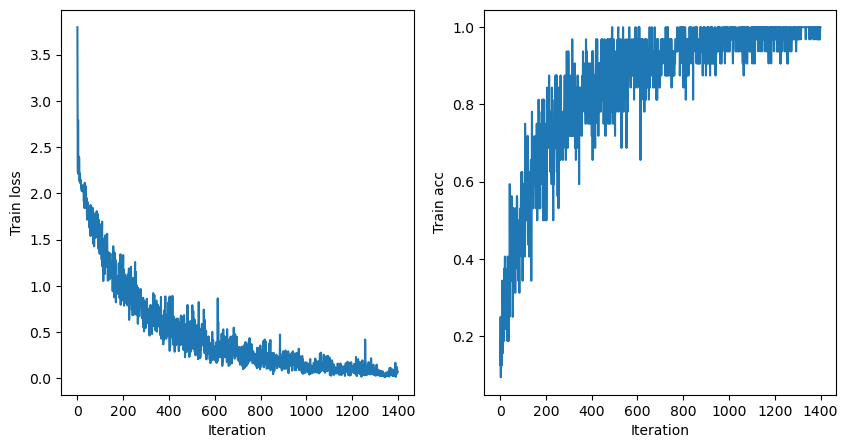

In [ ]:
train_audio_clfr(
    cnn,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
    num_epochs=10,
)

### CNN validation result

The convolutional model reaches **85.13% validation accuracy**, improving on the log-Mel LSTM. Most classes achieve strong recall, but `street_music` falls to 0.31 and is frequently confused with `children_playing`, indicating that the unaugmented CNN still learns class-specific shortcuts.

Val accuracy: 0.8513368983957219


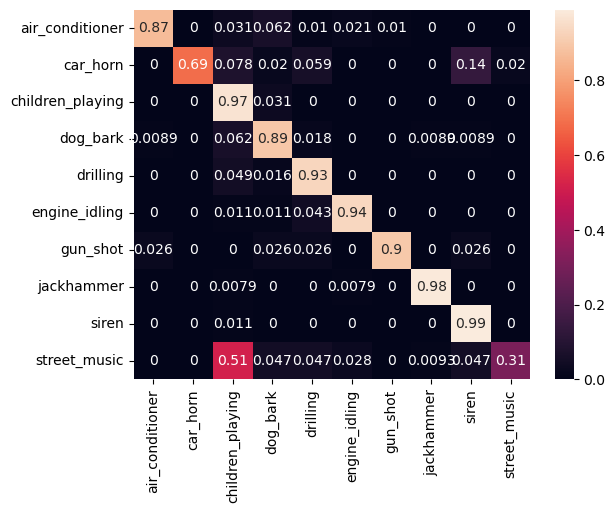

In [ ]:
plot_confusion_matrix(
    cnn,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

## SpecAugment regularization

With only 4,500 training clips, a high-capacity convolutional model can overfit. SpecAugment regularizes the model directly in the time–frequency domain by masking contiguous time intervals and Mel-frequency bands.

The augmentation is applied only during training. Masked regions are filled with the spectrogram mean, encouraging the classifier to distribute evidence across multiple temporal and spectral cues instead of depending on a narrow feature region.

In [ ]:
from random import randrange

class SpectAugment:
    def __init__(
        self,
        filling_value="mean",
        n_freq_masks=2,
        n_time_masks=2,
        max_freq=10,
        max_time=50,
    ):

        self.filling_value = filling_value
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks
        self.max_freq = max_freq
        self.max_time = max_time

    def __call__(self, spect, lens):
        # Apply stochastic time and frequency masks
        spect_aug = spect.clone()
        for i in range(32):
            for j in range(self.n_time_masks):

                t = randrange(0, self.max_time)
                t0 = randrange(0, spect_aug.shape[2] - t)

            if t0 == t0 + t:
                    return spect_aug, lens

            spect_aug[i][:, t0: t0 + t] = x_logmel.mean()

            for j in range(self.n_freq_masks):

                t = randrange(0, self.max_freq)
                t0 = randrange(0, spect_aug.shape[1] - t)

                if t0 == t0 + t:
                    return spect_aug, lens

            spect_aug[i][t0: t0 + t] = x_logmel.mean()

        return spect_aug, lens

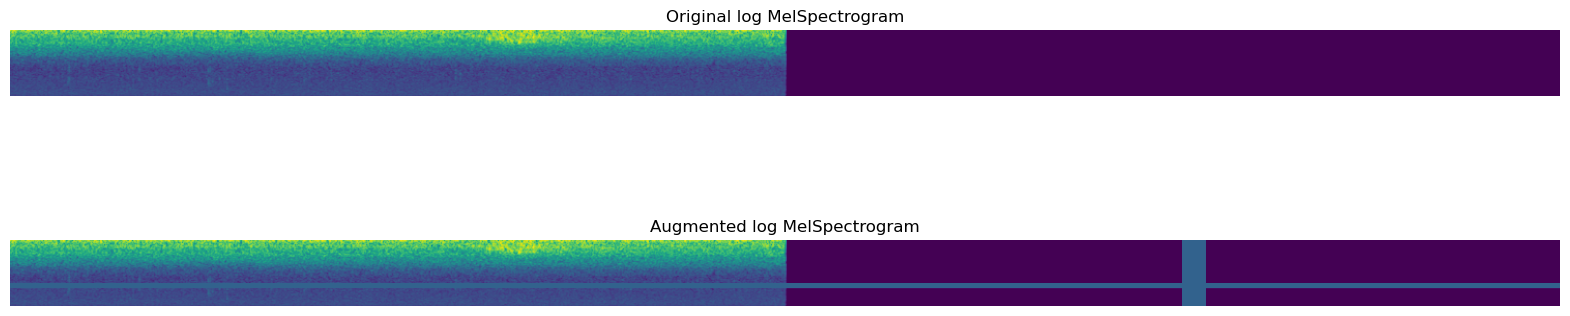

In [ ]:
# Apply augmentation to one mini-batch
for batch in train_dataloader:
    break

x = batch["x"].to(device)
lens = batch["len"].to(device)
x_logmel, lens = compute_log_melspectrogram_reference(
    x, lens, sr=train_dataset.sr, device=device
)
x_logmel_augmented, lens = SpectAugment()(x_logmel, lens)

# Compare original and augmented spectrograms
plt.figure(figsize=(20, 5))
plt.subplot(2, 1, 1)
plt.title("Original log MelSpectrogram")
plt.axis("off")
plt.imshow(x_logmel[0].cpu().numpy())

plt.subplot(2, 1, 2)
plt.title("Augmented log MelSpectrogram")
plt.axis("off")
plt.imshow(x_logmel_augmented[0].cpu().numpy())

plt.show()

In [ ]:
cnn = CNN10()
cnn.to(device)

optim = torch.optim.Adam(cnn.parameters(), lr=2e-4)

Epoch 19


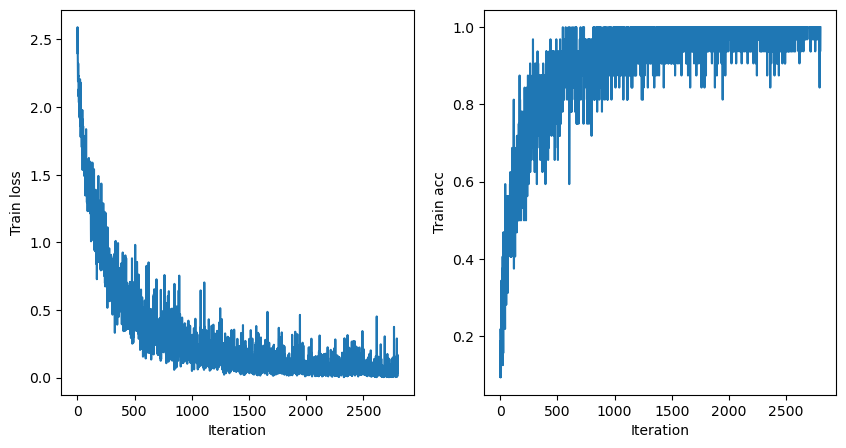

In [ ]:
# Train the CNN with SpecAugment
train_audio_clfr(
    cnn,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
    augmentation=SpectAugment(),
    num_epochs=20,
)

### Augmented CNN validation result

After 20 training epochs with time and frequency masking, the CNN reaches **92.73% validation accuracy**. The normalized confusion matrix is substantially more balanced than those of the earlier models: per-class recall ranges from approximately **0.84 to 0.99**. In particular, `street_music` improves from 0.31 to 0.90 recall, while `car_horn` improves from 0.69 to 0.94.

Val accuracy: 0.9272727272727272


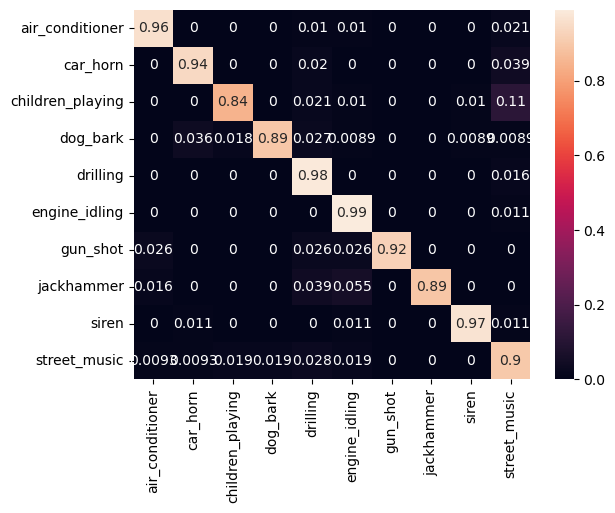

In [ ]:
plot_confusion_matrix(
    cnn,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

## Conclusions

The experiments demonstrate that representation choice and regularization have a larger effect than simply increasing model complexity.

| Model | Input representation | Validation accuracy |
|---|---|---:|
| Bidirectional LSTM | Raw waveform windows | 11.76% |
| Bidirectional LSTM | Log-Mel spectrogram | 82.67% |
| CNN | Log-Mel spectrogram | 85.13% |
| CNN + SpecAugment | Augmented log-Mel spectrogram | **92.73%** |

### Main findings

- Converting raw audio into log-Mel spectrograms improves validation accuracy by more than **70 percentage points**, confirming the importance of domain-specific feature engineering.
- The CNN slightly outperforms the recurrent log-Mel model because local two-dimensional filters match spectrogram structure well.
- SpecAugment delivers the largest improvement after feature extraction, adding **7.59 percentage points** over the unaugmented CNN and producing much more balanced per-class recall.
- The final model improves `street_music` recall from 0.31 to 0.90 and `car_horn` recall from 0.69 to 0.94, showing that augmentation addresses difficult class-specific failure modes rather than only improving the average.
- The manually implemented log-Mel pipeline matches torchaudio within $10^{-5}$, connecting signal-processing theory with a validated production library implementation.

### Recommended model

The **log-Mel CNN trained with SpecAugment** is the strongest model in this study. It combines the best overall accuracy with the most balanced confusion matrix and is therefore the preferred candidate for environmental-sound classification.

### Limitations and next steps

- Evaluate on a held-out test split and report macro-F1, precision, recall, and confidence intervals in addition to accuracy.
- Make device selection automatic and remove fixed assumptions about batch size and clip length.
- Generalize SpecAugment masking across arbitrary batch shapes and compare mean, minimum, and constant fill strategies.
- Add learning-rate scheduling, early stopping, reproducible random seeds, and experiment tracking.
- Compare against pretrained audio encoders such as PANNs, YAMNet, or wav2vec-style models.
- Investigate class balancing and targeted augmentation for the remaining difficult categories.